# Interpolate population from decadal to annual

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
# === Path config ===
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"

population_decade = xr.open_dataarray(f"{POP_DIR}ssp2_coarse_grid_2000-2100.nc")

# Create range of dates [2000, 2001, 2002, ..., 2100]
annual_range = range(population_decade.year[0].values,
                     (population_decade.year[-1]+1).values, 1)

# Interpolate across years
annual_population = population_decade.interp(year=annual_range)

description = ("Global time-series map of population counts (total populations)"
               " at 0.1ºx0.1º resolution, aggregated from 1km resolution by "
               "A.F. Wells consistent with the Shared Socioeconomic Pathways "
               "(SSPs).")
cite = ("Gao, J. (2017). Downscaling global spatial population projections"
        " from 1/8-degree to 1-km grid cells. NCAR Technical Note "
        "NCAR/TN-537+STR, National Center for Atmospheric Researcher, "
        "Boulder, CO., USA. DOI: 10.5065/D60Z721H")
annual_population.to_netcdf(f"{POP_DIR}ssp2_coarse_grid_annual_2000-2100.nc")

print("All processing complete.")

Sanity check the interpolation

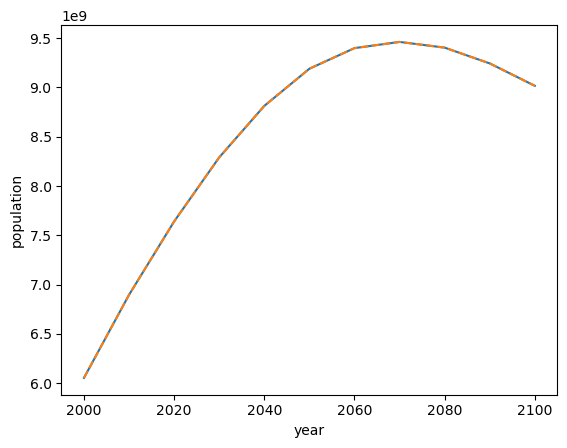

In [3]:
population_decade.sum(dim=("lat", "lon")).plot()
annual_population.sum(dim=("lat", "lon")).plot(linestyle="--")

plt.show()